### **[Uncertainty Quantification in Time Series Forecasting](https://medium.com/the-forecaster/sample-paths-for-uncertainty-quantification-in-time-series-forecasting-eec5da283db6)**

In [1]:
!pip install -qq neuralforecast utilsforecast timeseriesviz pytorch-lightning

In [2]:
import sys
import logging
import warnings

from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from utilsforecast.plotting import plot_series
from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import MQLoss
from neuralforecast.models import NHITS
from timeseriesviz import plot_neuralforecast

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option("display.width", None)
pd.set_option("display.precision", 4)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["figure.dpi"] = 200

%autosave 10

Autosaving every 10 seconds


In [4]:
def profile_dataset(filepath: str) -> None:
  df = pd.read_csv(filepath, parse_dates=["ds"])

  print("=== DATASET PROFILE ===\n")
  print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
  print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

  summary = pd.DataFrame({
    "rows":    df.shape[0],
    "columns": df.shape[1],
    "dtype":   df.dtypes,
    "nulls":   df.isnull().sum(),
    "null_%":  (df.isnull().mean() * 100).round(2),
    "unique":  df.nunique(),
    "sample":  df.iloc[0]
  })

  display(summary) ## print(summary.to_string())

In [5]:
url = "https://raw.githubusercontent.com/marcopeix/youtube_tutorials/refs/heads/main/data/daily_sales_french_bakery.csv"
data = pd.read_csv(url, parse_dates=["ds"])
df = data[data["unique_id"] == "BAGUETTE"]
df = df.drop(columns=["unit_price"])

profile_dataset(url)

=== DATASET PROFILE ===

Rows: 57,046  |  Columns: 4
Memory usage: 4.63 MB



,rows,columns,dtype,nulls,null_%,unique,sample
unique_id,57046,4,object,0,0.0000,148,12 MACARON
ds,57046,4,datetime64[ns],0,0.0000,637,2022-07-13 00:00:00
y,57046,4,float64,0,0.0000,1286,10.0000
unit_price,57046,4,float64,0,0.0000,96,10.0000


In [6]:
display(df.sample(10))

,unique_id,ds,y
344,BAGUETTE,2021-09-19,35.1000
312,BAGUETTE,2021-08-18,49.5000
115,BAGUETTE,2021-02-02,21.6000
591,BAGUETTE,2022-05-24,19.0000
587,BAGUETTE,2022-05-20,27.5500
114,BAGUETTE,2021-02-01,13.5000
712,BAGUETTE,2022-09-22,34.0000
194,BAGUETTE,2021-04-22,27.0000
331,BAGUETTE,2021-09-06,34.2000
606,BAGUETTE,2022-06-08,34.2000


In [7]:
HORIZON = 7

nhits = NHITS(
  h=HORIZON,
  input_size=4*HORIZON,
  loss=MQLoss(level=[80,90]),
  scaler_type="robust",
  max_steps=1000,
)

nf = NeuralForecast(models=[nhits], freq="D")

nf.fit(df)

Epoch 999/-2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s v_num: 0.000 train_loss_step: 0.040 
                                                                               train_loss_epoch: 0.040             

Output()

<Figure size 2400x1600 with 0 Axes>

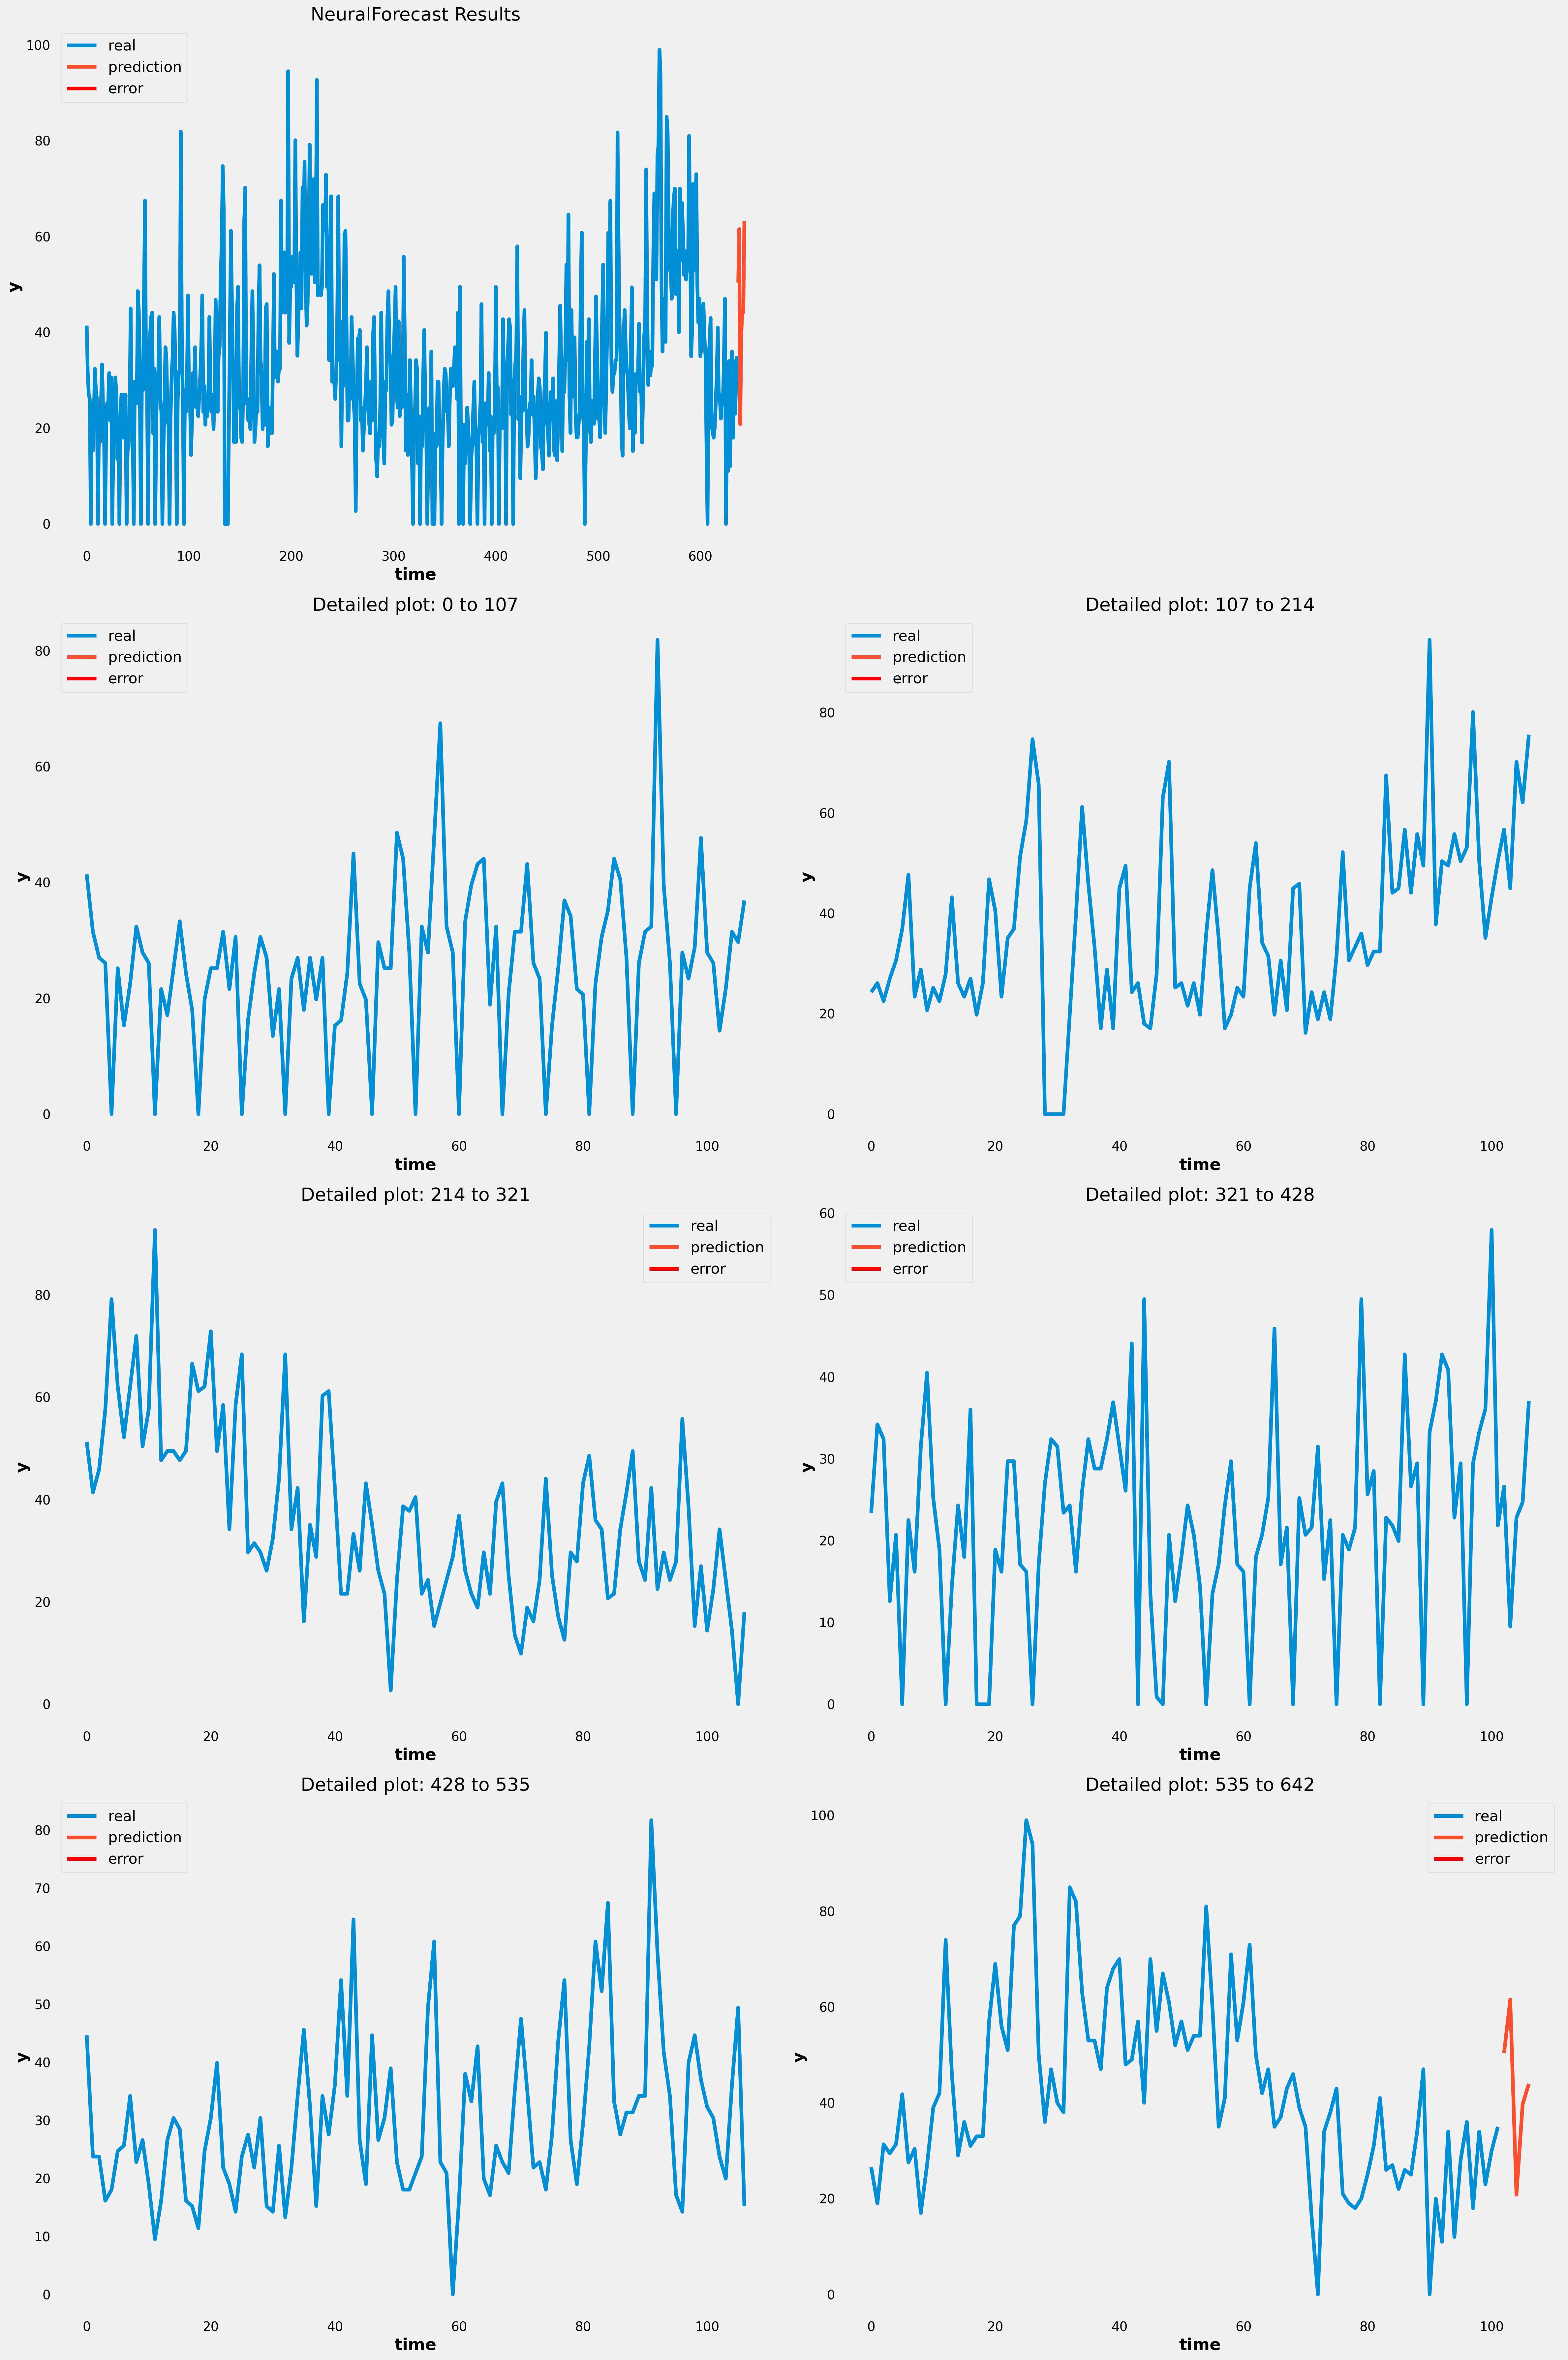

In [9]:
fcsts = nf.predict()
fcsts_renamed = fcsts.rename(columns={"NHITS-median": "NHITS"})

all_ids_dates = pd.concat([df[['unique_id', 'ds']], fcsts[['unique_id', 'ds']]]).drop_duplicates()

plot_df = pd.merge(all_ids_dates, df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
plot_df = pd.merge(plot_df, fcsts_renamed[['unique_id', 'ds', 'NHITS']], on=['unique_id', 'ds'], how='left')

fig, axs = plot_neuralforecast(plot_df, model_name="NHITS", title="NeuralForecast Results", splitsize=6)

Output()

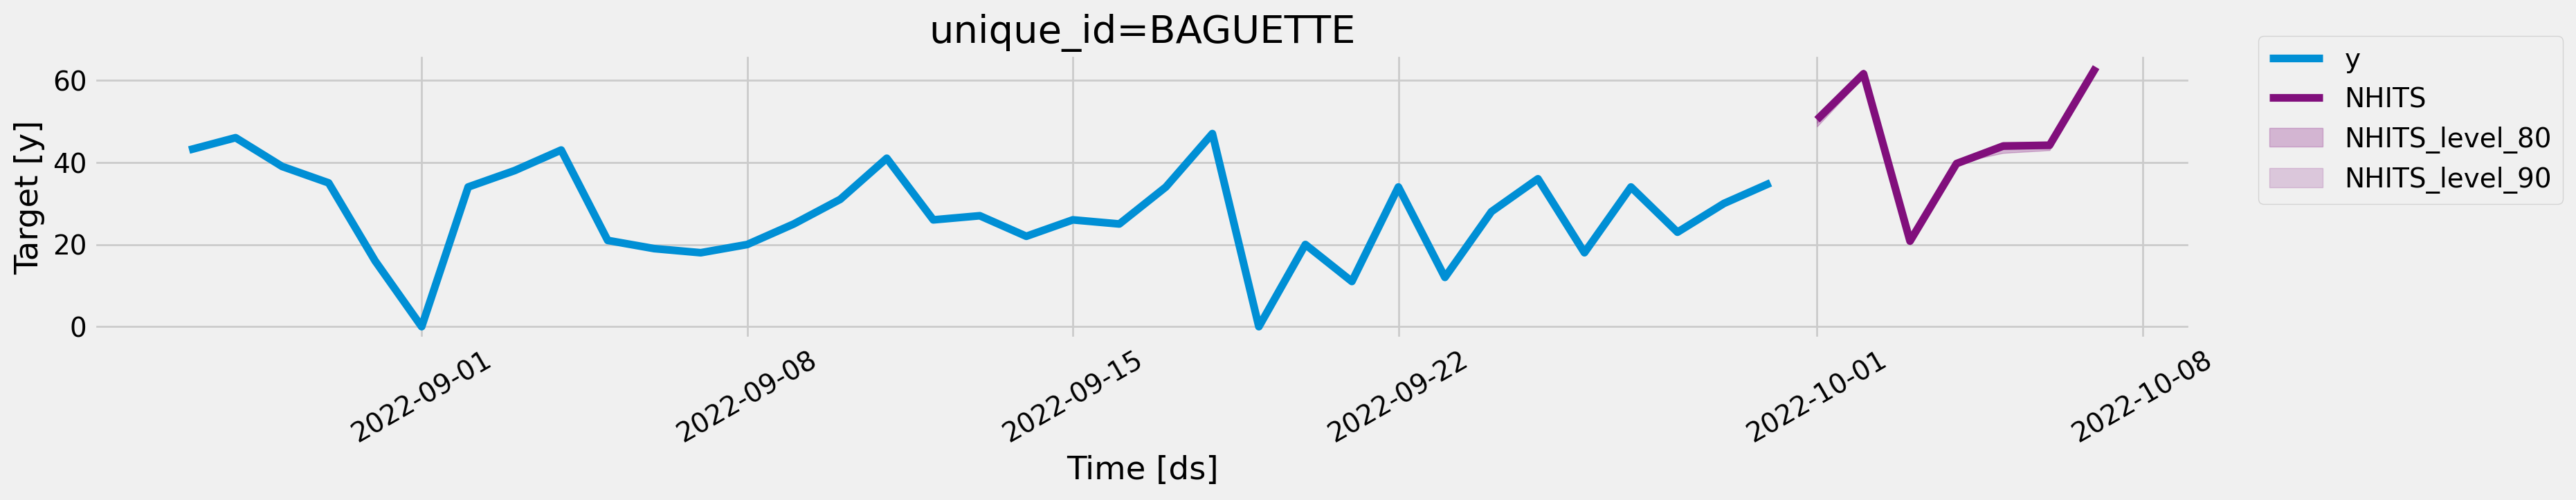

In [10]:
fcsts = nf.predict()
fcsts = fcsts.rename(columns={"NHITS-median": "NHITS"})

plot_series(df, fcsts, level=[80, 90], max_insample_length=5*HORIZON)

In [11]:
N_PATHS = 100
SEED = 42

sample_paths_df = nf.simulate(n_paths=N_PATHS, seed=SEED)

Output()

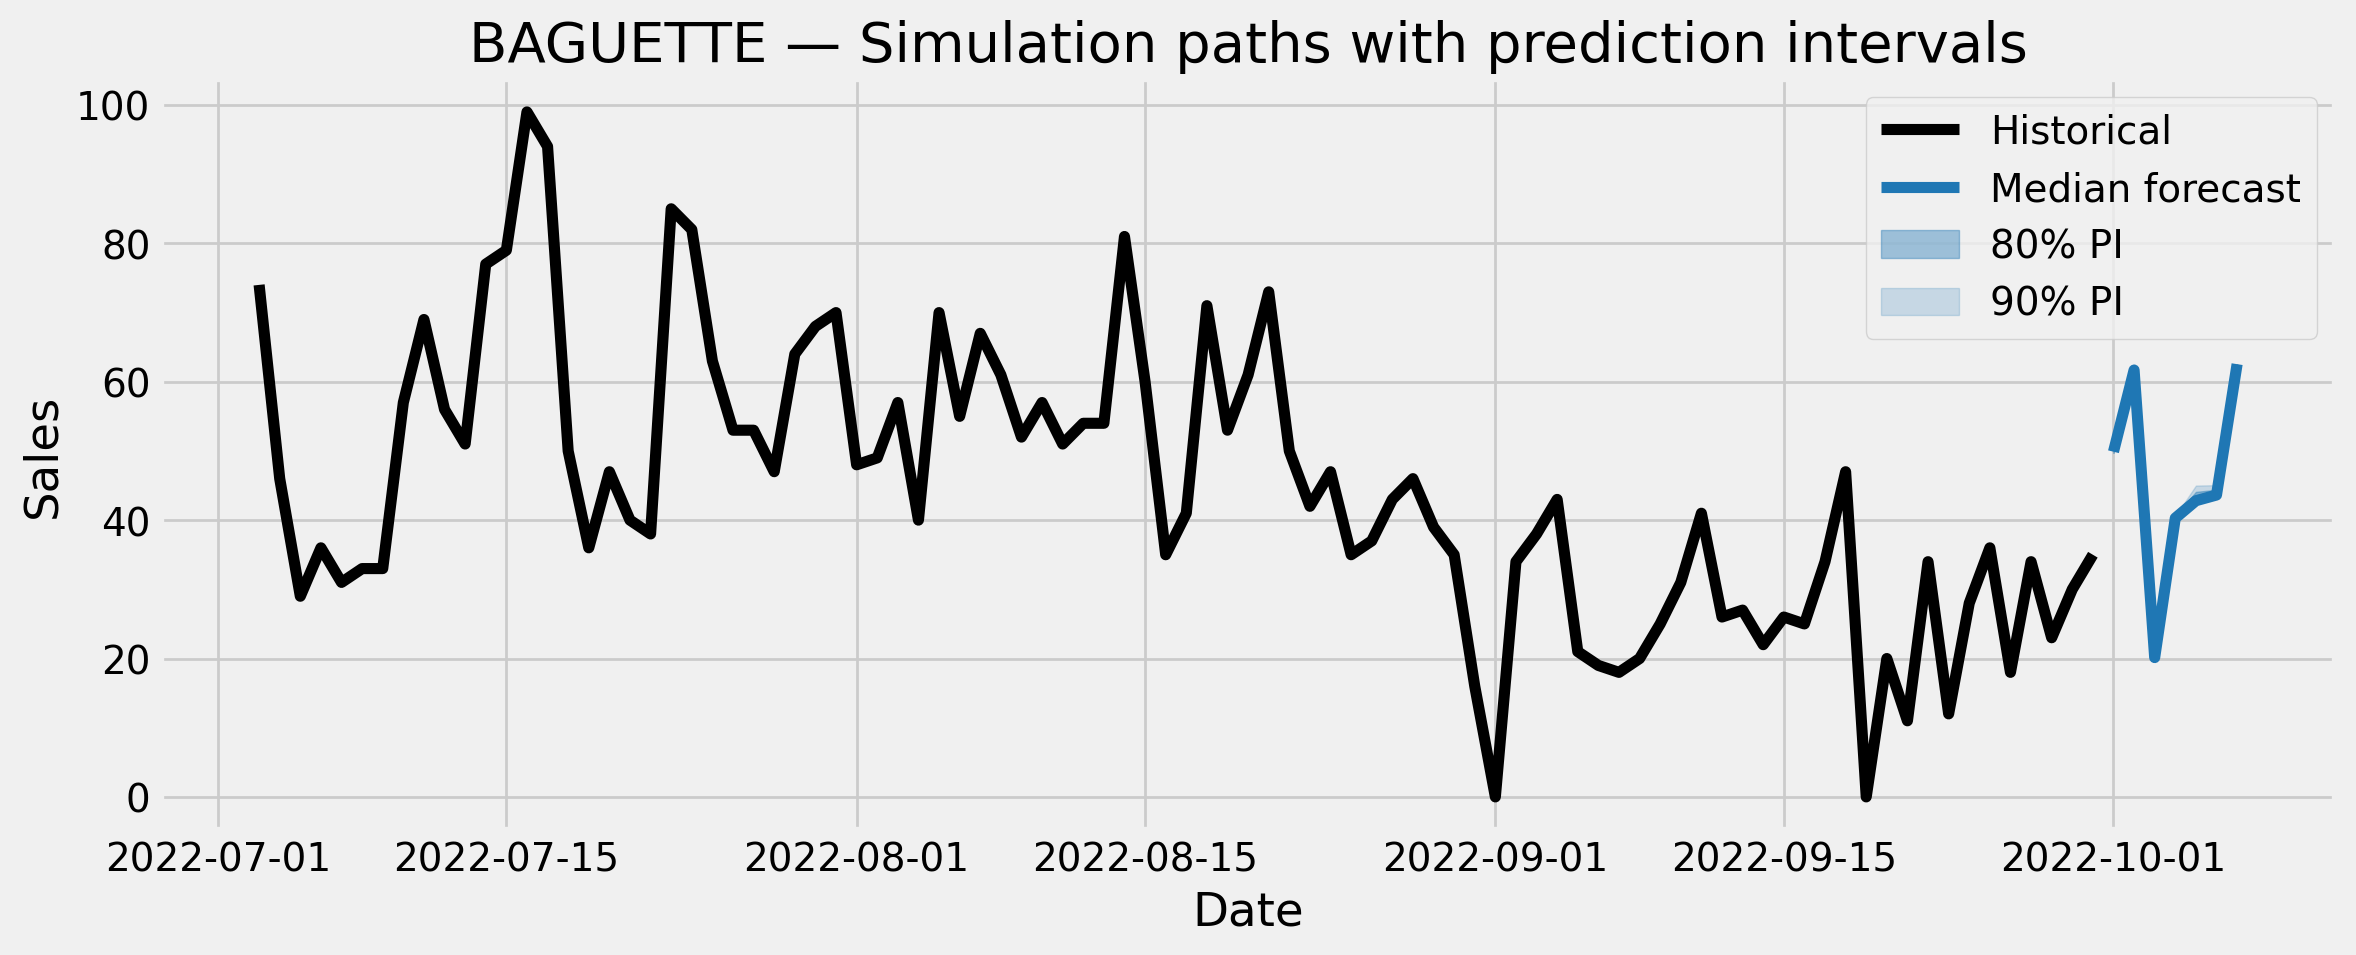

In [12]:
def plot_sample_paths_intervals(df, sample_paths_df, unique_id, n_hist=90, model_col="NHITS"):
  series_df = df[df["unique_id"] == unique_id].tail(n_hist)
  paths = sample_paths_df[sample_paths_df["unique_id"] == unique_id]

  intervals = paths.groupby("ds")[model_col].quantile([0.05, 0.10, 0.90, 0.95]).unstack()
  intervals.columns = ["lo_90", "lo_80", "hi_80", "hi_90"]
  intervals = intervals.reset_index()

  median = paths.groupby("ds")[model_col].median().reset_index()

  fig, ax = plt.subplots(figsize=(12, 5))

  ax.plot(series_df["ds"], series_df["y"], color="black", label="Historical")
  ax.plot(median["ds"], median[model_col], color="#1f77b4", label="Median forecast")
  ax.fill_between(intervals["ds"], intervals["lo_80"], intervals["hi_80"], alpha=0.4, color="#1f77b4", label="80% PI")
  ax.fill_between(intervals["ds"], intervals["lo_90"], intervals["hi_90"], alpha=0.2, color="#1f77b4", label="90% PI")

  ax.set_title(f"{unique_id} — Simulation paths with prediction intervals")
  ax.set_xlabel("Date")
  ax.set_ylabel("Sales")
  ax.legend()
  plt.tight_layout()
  plt.show()

plot_sample_paths_intervals(df, sample_paths_df, unique_id="BAGUETTE")

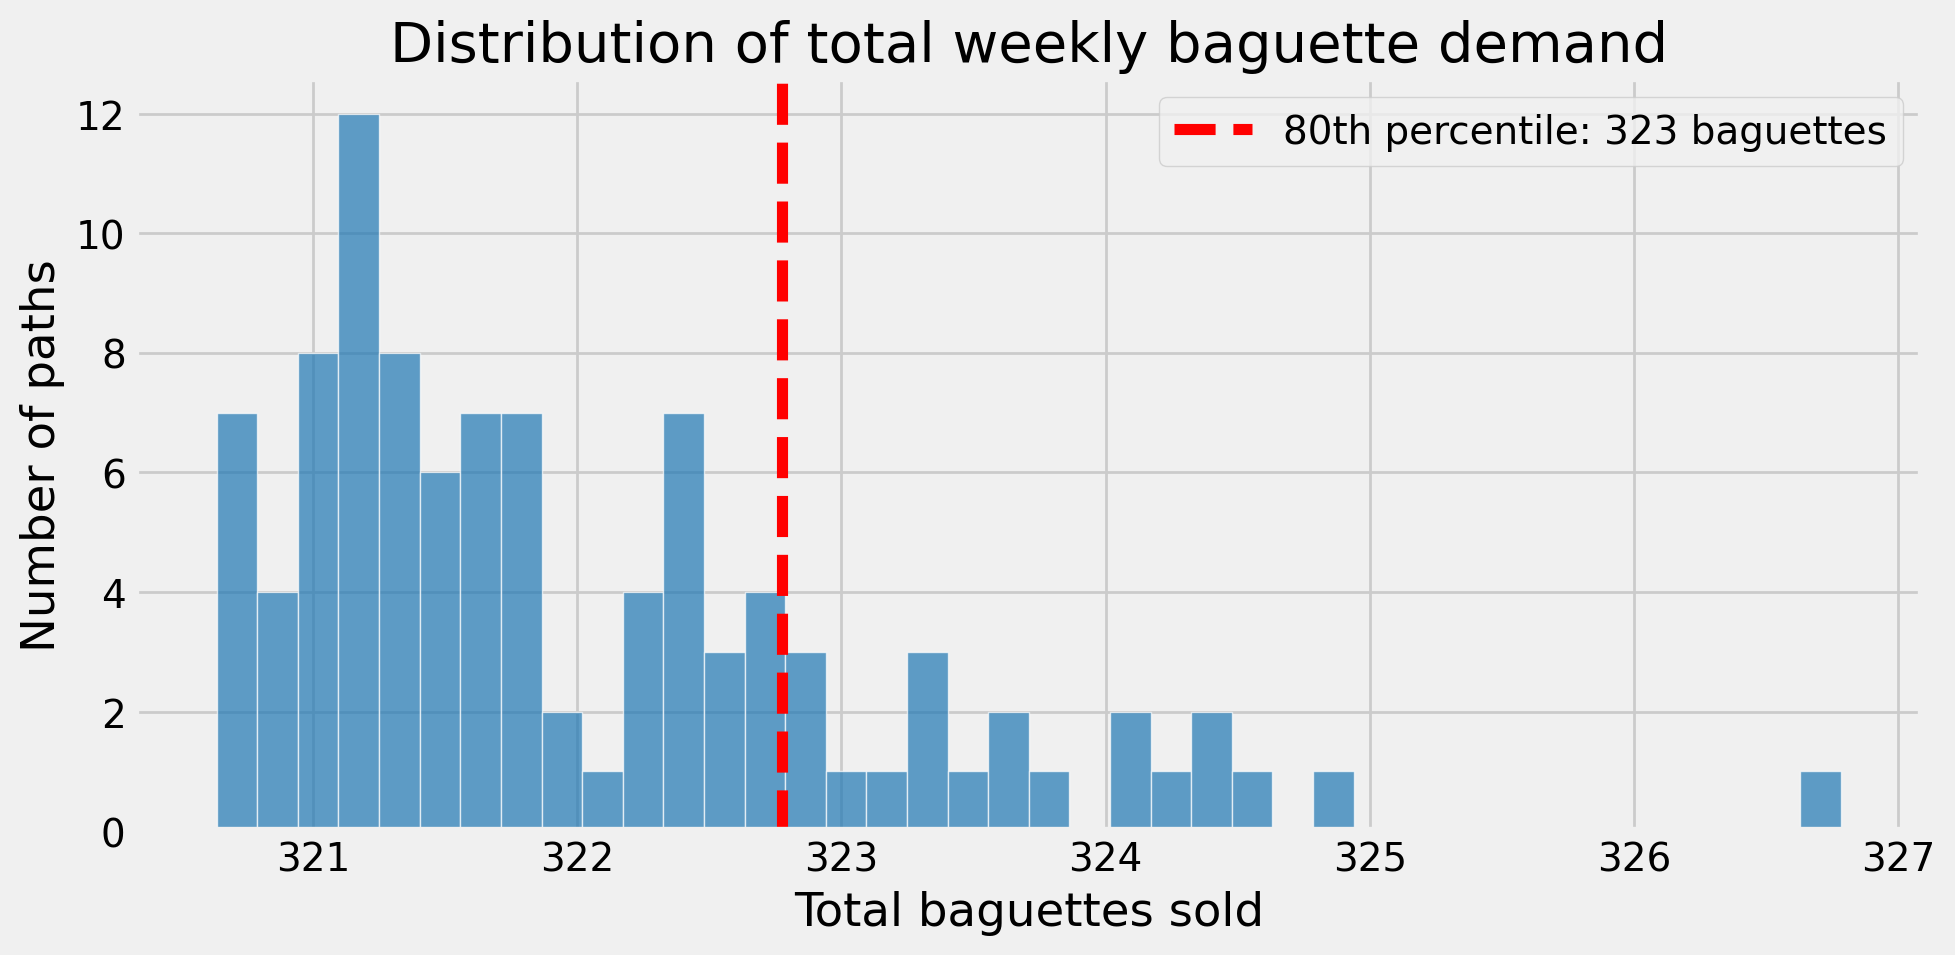

Bake 323 baguettes to serve 80% of weekly demand


In [13]:
weekly_demand = sample_paths_df.groupby("sample_id")["NHITS"].sum()
target = weekly_demand.quantile(0.80)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(weekly_demand, bins=40, color="#1f77b4", alpha=0.7, edgecolor="white")
ax.axvline(target, color="red", linestyle="--", label=f"80th percentile: {target:.0f} baguettes")

ax.set_title("Distribution of total weekly baguette demand")
ax.set_xlabel("Total baguettes sold")
ax.set_ylabel("Number of paths")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Bake {target:.0f} baguettes to serve 80% of weekly demand")

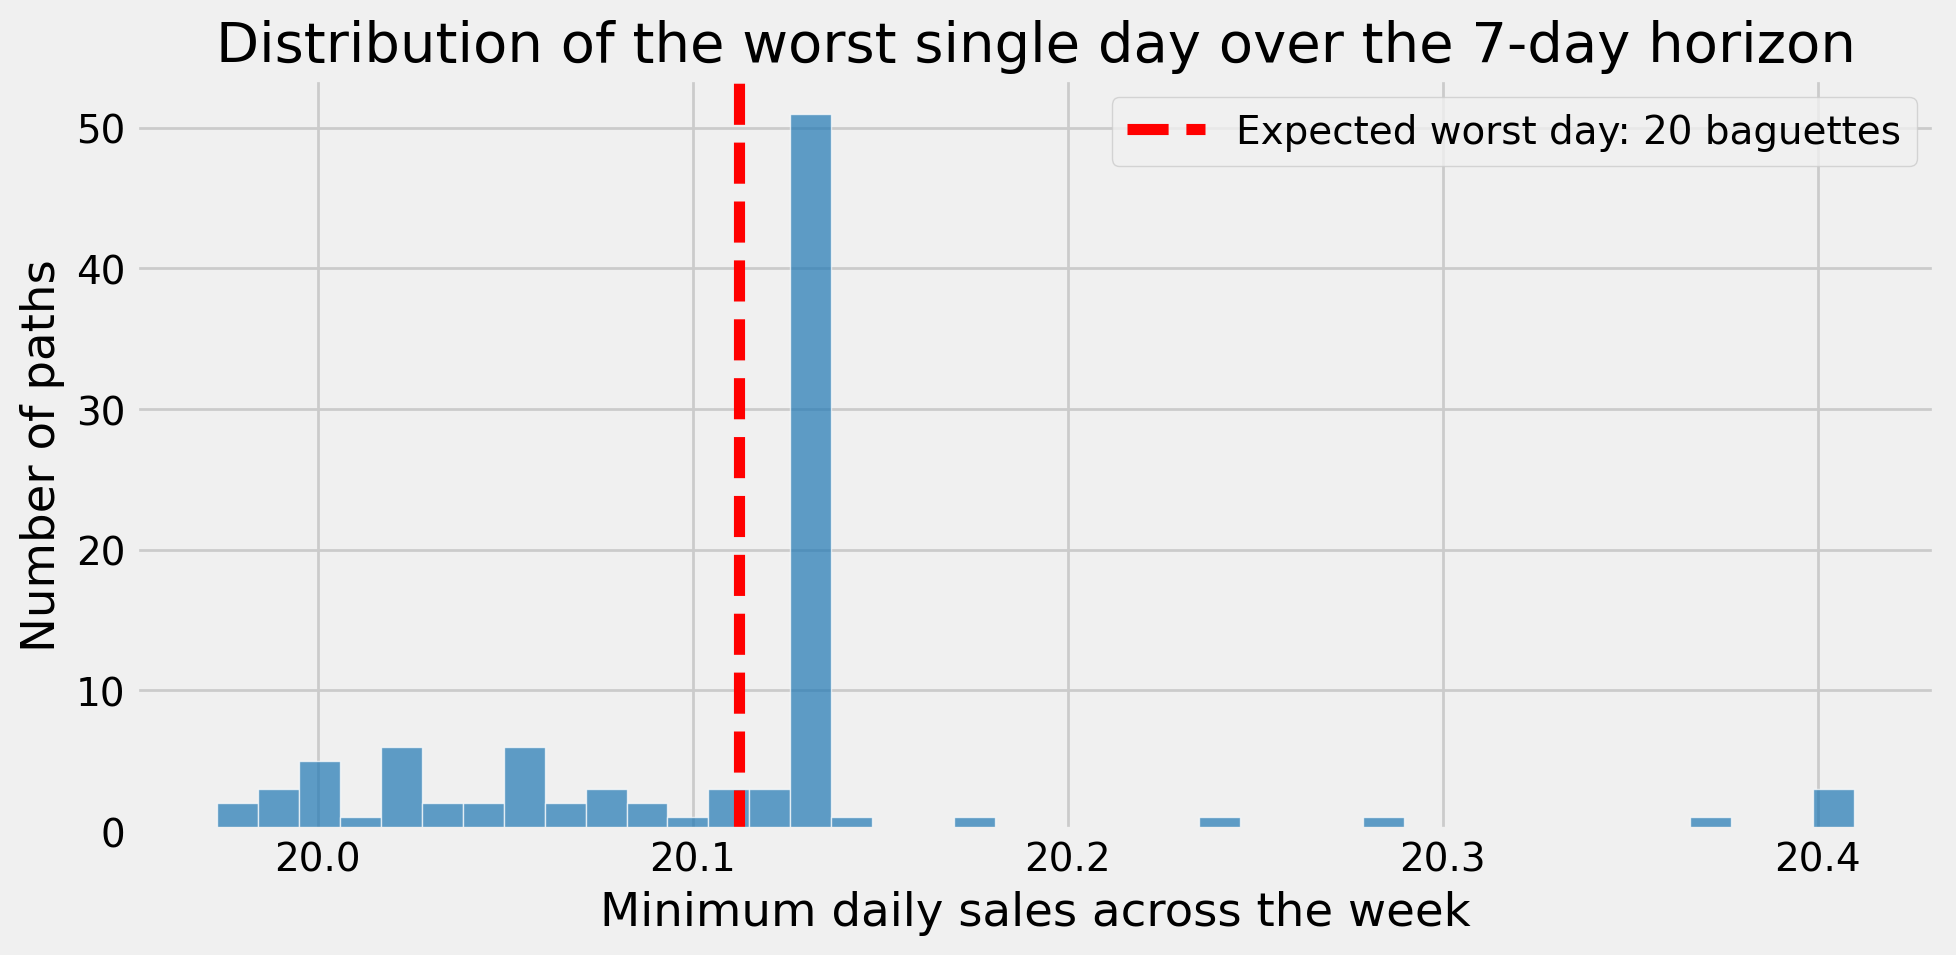

Expected worst single day: 20 baguettes


In [14]:
worst_day = sample_paths_df.groupby("sample_id")["NHITS"].min()
expected_worst = worst_day.mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(worst_day, bins=40, color="#1f77b4", alpha=0.7, edgecolor="white")
ax.axvline(expected_worst, color="red", linestyle="--", label=f"Expected worst day: {expected_worst:.0f} baguettes")

ax.set_title("Distribution of the worst single day over the 7-day horizon")
ax.set_xlabel("Minimum daily sales across the week")
ax.set_ylabel("Number of paths")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Expected worst single day: {expected_worst:.0f} baguettes")